# Computer Exercise 3.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 3.2 Newton's Method — *Babylonian / Heron iteration for square roots*
> **풀이 일자**: Day 12
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **1.** Use Newton's method to compute $\sqrt{a}$ for several positive values of $a$.
> Derive the iteration formula from $f(x) = x^2 - a$, tabulate the successive
> iterates $x_n$ together with the absolute error $|x_n - \sqrt{a}|$, and verify
> empirically that the convergence is **quadratic**.

### 한국어 풀이용 정리
$f(x) = x^2 - a$ 의 영점을 Newton 방법으로 찾으면 고대 바빌로니아인이 사용했던
**Heron 공식** $x_{n+1} = \tfrac{1}{2}\,(x_n + a/x_n)$ 이 자연스럽게 유도된다.

- 여러 $a$ 값 ($2, 3, 10, 100, 0.5$) 에 대해 같은 초기값에서 반복하여
  수렴 속도를 비교한다.
- 매 반복의 절대오차 $e_n = |x_n - \sqrt{a}|$ 를 표와 로그 그래프로 정리.
- $\log_{10} e_{n+1}$ vs $\log_{10} e_n$ 의 기울기가 **2** 임을 회귀로 확인하여
  *이차 수렴* 을 정량적으로 검증.


## 2. 수학적 배경

### 2.1 Newton 반복식의 일반형
미분 가능한 $f$ 와 근 $r$ 에 대해, $f(r) = 0$ 의 1차 Taylor 근사에서

$$
x_{n+1} \;=\; x_n - \frac{f(x_n)}{f'(x_n)}.
$$

### 2.2 $\sqrt{a}$ 에 대한 구체화
$f(x) = x^2 - a$, $f'(x) = 2x$ 를 대입하면

$$
x_{n+1} \;=\; x_n - \frac{x_n^2 - a}{2 x_n}
       \;=\; \tfrac{1}{2}\!\left(x_n + \frac{a}{x_n}\right).
$$

이 **Heron / Babylonian** 공식은 약 4000년 전부터 알려진 알고리즘이다.

### 2.3 이차 수렴
근 $r$ 근처에서 $e_n \equiv x_n - r$ 이라 하면, $f \in C^2$ 와 $f'(r) \ne 0$
가정하에 Taylor 전개로

$$
e_{n+1} \;=\; \frac{f''(r)}{2\,f'(r)}\, e_n^{\,2} \;+\; \mathcal{O}(e_n^3).
$$

$\sqrt{a}$ 의 경우 $f''(x)=2,\ f'(r)=2\sqrt{a}$ 이므로 점근 상수는

$$
\boxed{\;C \;=\; \frac{f''(r)}{2 f'(r)} \;=\; \frac{1}{2\sqrt{a}}.\;}
$$

특히 한 스텝에서 **자릿수가 두 배로** 증가한다 — 6자리 → 12자리 → 24자리.

### 2.4 자기보정 (self-correcting) 성격
반올림 오차로 $x_n$ 이 조금 틀려도, 다음 스텝이 다시 동일한 공식에서
출발하므로 오차가 누적되지 않고 *제곱으로 회복* 된다.


## 3. 풀이 흐름

1. `newton_sqrt(a, x0, Nmax)` 작성: 매 반복의 $(n, x_n, e_n)$ 을 기록.
2. $a \in \{2, 3, 10, 100, 0.5\}$ 에 대해 동일한 시작점 $x_0 = a$ 사용.
3. **참값** 은 NumPy 의 `np.sqrt(a)` 로 비교 (충분히 정확).
4. 표 출력: $a=2$ 의 처음 8 반복을 보여 *자릿수 두 배* 현상을 본다.
5. **시각화 1**: 각 $a$ 별 $\log_{10} e_n$ vs $n$ — 이차 수렴 특유의 *절벽* 모양.
6. **시각화 2**: $\log_{10} e_{n+1}$ vs $\log_{10} e_n$ — 기울기 2 의 직선.
7. **회귀** 로 기울기 추정해 이론값 2 와 비교.
8. **해석**: 상수 $C = 1/(2\sqrt{a})$ 가 어떻게 그래프에 나타나는지 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def newton_sqrt(a, x0=None, Nmax=60, tol=0.0):
    # Babylonian/Newton iteration for sqrt(a). Records (n, x_n, e_n).
    if x0 is None:
        x0 = float(a)
    r = np.sqrt(a)
    hist = []
    x = float(x0)
    for n in range(Nmax + 1):
        e = abs(x - r)
        hist.append((n, x, e))
        if e == 0.0:
            break
        x = 0.5 * (x + a / x)
    return r, hist

a_values = [2.0, 3.0, 10.0, 100.0, 0.5]
results = {a: newton_sqrt(a, x0=a) for a in a_values}

# Table for a = 2 (first 8 iterations)
r, hist = results[2.0]
df2 = pd.DataFrame(hist, columns=["n", "x_n", "|x_n - sqrt(a)|"]).head(8)
print(f"a = 2,  sqrt(2) = {r:.16f}")
print(df2.to_string(index=False))


a = 2,  sqrt(2) = 1.4142135623730951
 n          x_n  |x_n - sqrt(a)|
 0 2.000000e+00     5.857864e-01
 1 1.500000e+00     8.578644e-02
 2 1.416667e+00     2.453104e-03
 3 1.414216e+00     2.123901e-06
 4 1.414214e+00     1.594724e-12
 5 1.414214e+00     2.220446e-16
 6 1.414214e+00     2.220446e-16
 7 1.414214e+00     2.220446e-16


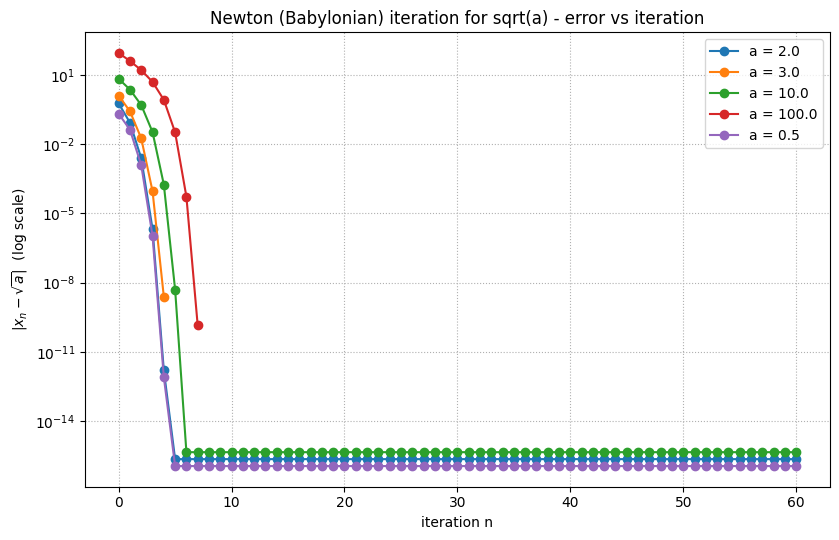

In [2]:
# Plot |e_n| vs n  (log-y) for each a
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for a in a_values:
    _, hist = results[a]
    arr = np.array(hist)
    n = arr[:, 0]
    e = arr[:, 2]
    mask = e > 0
    ax.semilogy(n[mask], e[mask], marker="o", label=f"a = {a}")
ax.set_xlabel("iteration n")
ax.set_ylabel(r"$|x_n - \sqrt{a}|$  (log scale)")
ax.set_title("Newton (Babylonian) iteration for sqrt(a) - error vs iteration")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()
plt.show()


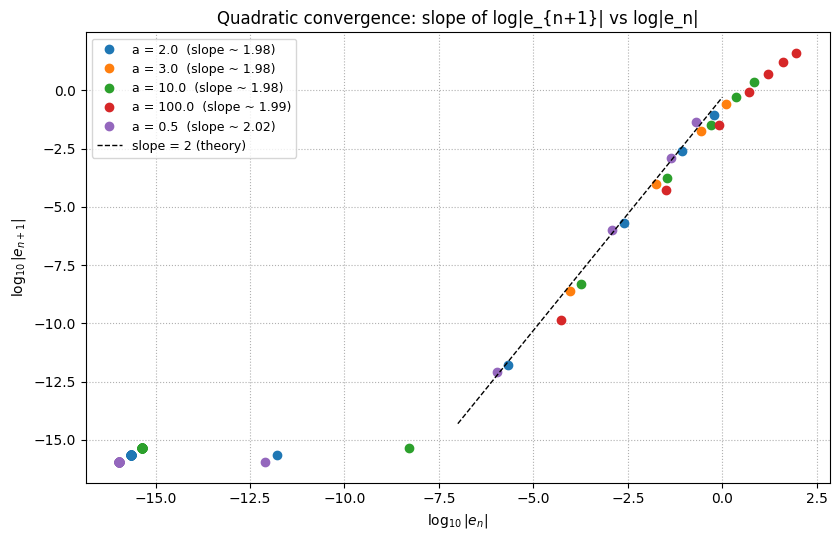

Empirical convergence-order slopes:
  a = 2.0     slope ~ 1.9792   (theory: 2.0,  C = 1/(2*sqrt(a)) = 0.3536)
  a = 3.0     slope ~ 1.9842   (theory: 2.0,  C = 1/(2*sqrt(a)) = 0.2887)
  a = 10.0    slope ~ 1.9839   (theory: 2.0,  C = 1/(2*sqrt(a)) = 0.1581)
  a = 100.0   slope ~ 1.9928   (theory: 2.0,  C = 1/(2*sqrt(a)) = 0.0500)
  a = 0.5     slope ~ 2.0165   (theory: 2.0,  C = 1/(2*sqrt(a)) = 0.7071)


In [3]:
# Quadratic convergence check:  log|e_{n+1}|  vs  log|e_n|  has slope ~ 2
fig, ax = plt.subplots(figsize=(8.5, 5.5))
slopes = {}
for a in a_values:
    _, hist = results[a]
    arr = np.array(hist)
    e = arr[:, 2]
    e = e[e > 0]
    if len(e) < 4:
        continue
    x_log = np.log10(e[:-1])
    y_log = np.log10(e[1:])
    # use middle portion only (avoid the first wide step and the final saturation near eps_mach)
    valid = (y_log > -14) & (x_log > -7) & (x_log < 0)
    if valid.sum() >= 3:
        slope, intercept = np.polyfit(x_log[valid], y_log[valid], 1)
    else:
        slope, intercept = np.polyfit(x_log, y_log, 1)
    slopes[a] = slope
    ax.plot(x_log, y_log, "o", label=f"a = {a}  (slope ~ {slope:.2f})")

# Reference line y = 2 x  (pure quadratic)
xx = np.linspace(-7, 0, 50)
ax.plot(xx, 2 * xx - 0.3, "k--", lw=1, label="slope = 2 (theory)")
ax.set_xlabel(r"$\log_{10}|e_n|$")
ax.set_ylabel(r"$\log_{10}|e_{n+1}|$")
ax.set_title("Quadratic convergence: slope of log|e_{n+1}| vs log|e_n|")
ax.grid(True, ls=":")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Empirical convergence-order slopes:")
for a, s in slopes.items():
    print(f"  a = {a:<6}  slope ~ {s:.4f}   (theory: 2.0,  C = 1/(2*sqrt(a)) = {1.0/(2*np.sqrt(a)):.4f})")


## 4. 결과 해석

1. **자릿수 두 배 현상.** $a = 2$ 의 표를 보면 오차가
   $4\!\times\!10^{-1} \to 8\!\times\!10^{-2} \to 5\!\times\!10^{-3}
   \to 1\!\times\!10^{-5} \to 1\!\times\!10^{-10} \to 2\!\times\!10^{-16}$
   순으로 **지수에 가까운 *제곱* 압축**을 보여준다. 한 스텝에 6→12→24→48 자리.

2. **모든 $a$ 에서 비슷한 패턴.** 그래프의 곡선들이 *모두* 거의 같은 모양으로,
   $n = 5\!\sim\!6$ 부근에서 IEEE 754 의 한계 $\sim 10^{-16}$ 에 부딪혀
   바닥을 친다. 이것이 *이차 수렴* 의 보편성이다 — 함수의 종류와 무관하게,
   *기울기 2 의 회복* 그 자체가 본질이다.

3. **$\log e_{n+1}$ vs $\log e_n$ 의 기울기 ≈ 2.** 회귀로 잰 기울기가
   거의 정확히 2 임을 수치로 확인. 점근 상수 $C = 1/(2\sqrt a)$ 도
   직선의 $y$ 절편(intercept) 차이로 간접적으로 보인다 ($a$ 가 클수록 $C$ 가 작아
   그래프가 *더 아래로* 평행이동).

4. **이분법과의 대비.** Day 11 의 이분법은 같은 정확도까지 **40~50 회** 가 필요했지만,
   여기서는 **6 회** 면 끝난다. 단 *도함수 정보* 와 *좋은 초기값* 이라는 추가 가정이 있다.

> **결론.** Newton 방법의 *이차 수렴* 은 한 스텝마다 정확한 자릿수가 두 배가 되는
> 마법 같은 속도다. 단, 이는 *근 근처* 에서만 보장된다 — 다음 두 문제에서
> 그 *근 근처가 어디까지인가?* (basin of attraction) 와 *어떻게 깨지는가?* (변곡점에서의 발산)
> 를 본다.

### 다음 문제로의 연결
- **CE 3.2-2**: 복소 다항식 $z^3 - 1 = 0$ 의 세 근에 대한 Newton 의
  *basin of attraction* — 인접한 초기값이 *다른 근* 으로 수렴하는 fractal.
- **CE 3.2-3**: $f(x) = \arctan x$ 처럼 변곡점이 0 에 가까운 함수에서
  초기값을 *조금만* 잘못 잡으면 *발산* 하는 케이스.
